In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import joblib
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [4]:
data = pd.read_csv('house_prices_dataset.csv')
data.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [5]:
df = data.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [6]:
for column in df.columns:
    print(f"Unique values in '{column}': {df[column].unique()}")

Unique values in 'square_feet': [2248.35707651 1930.86784941 2323.84426905 ... 1647.34163804 2247.88278651
 2322.19422677]
Unique values in 'num_rooms': [3 2 6 7 5 4]
Unique values in 'age': [92 22 33 63 54 70  8  3 65 90 32 31 43 36 91 66 59 58 35 48 50  7 49 40
 37 85 77 78 67 17 64 11 41 80 82 47 72 24  6 87 75 30 56 26 45 60 57 12
 52 99 34 93 94 16 71  9 95 28 74 76  4 19 20 81 51 89 18 53 14 62 27 79
 97 39 55 46 42  5  2 73 86 25 15 38 84 44  0 68 88 98 29 10 23 96 21 61
 83 69  1 13]
Unique values in 'distance_to_city(km)': [22.99797168 13.9842538  21.50094492 ...  2.18931243 27.9310137
 10.59572126]
Unique values in 'price': [200374.09041043 268784.84733716 315020.85767621 ... 233698.38430115
 280766.82737854 342895.30911361]


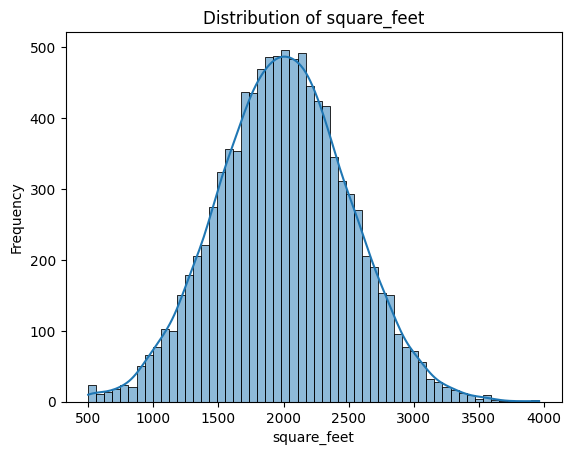

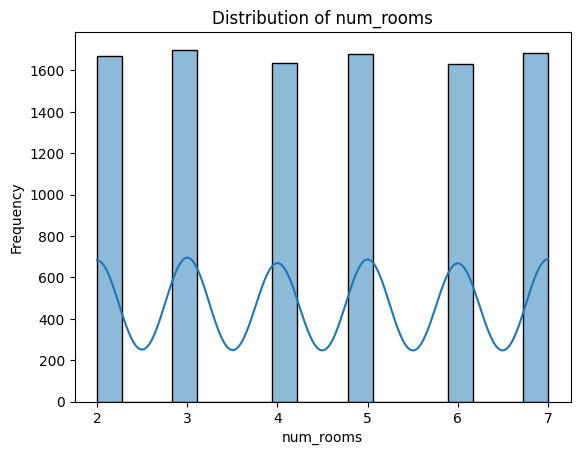

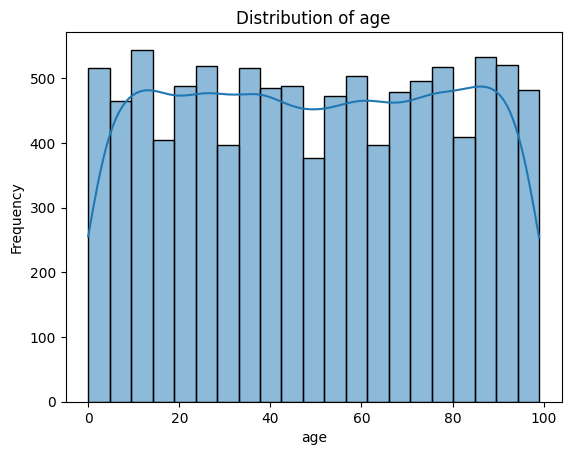

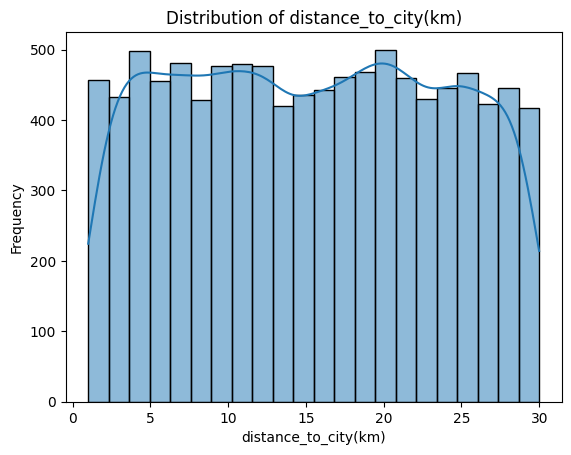

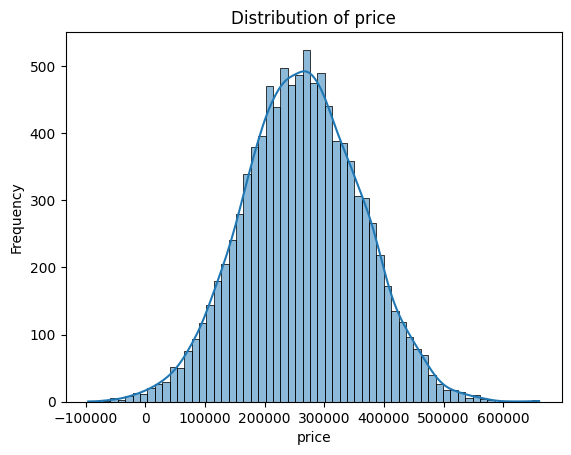

In [8]:
for column in df.columns:
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()  

Text(0.5, 1.0, 'Area vs Price')

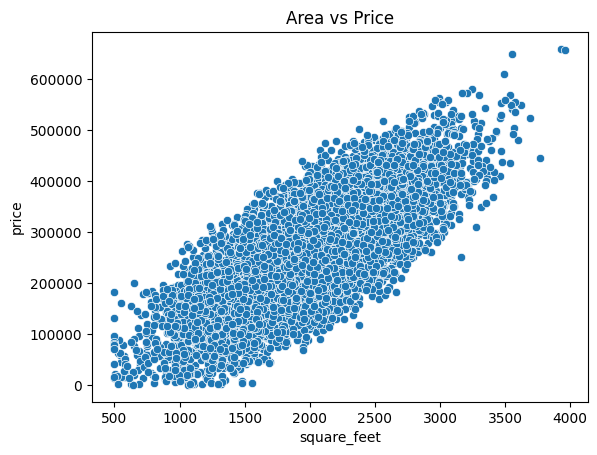

In [74]:
sns.scatterplot(x='square_feet', y='price', data=df)
plt.title("Area vs Price")

Text(0.5, 1.0, 'Area vs Price')

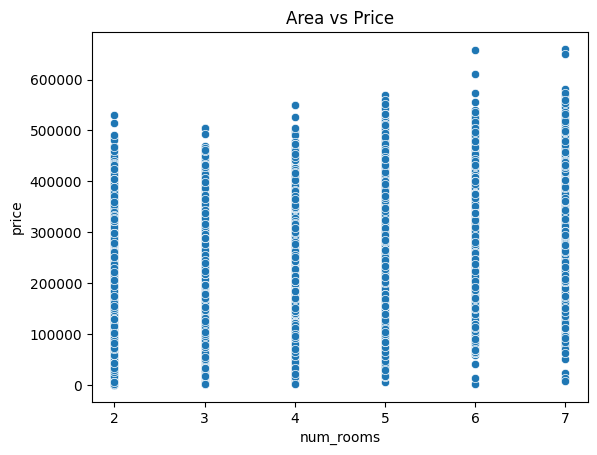

In [75]:
sns.scatterplot(x='num_rooms', y='price', data=df)
plt.title("Area vs Price")

Text(0.5, 1.0, 'Area vs Price')

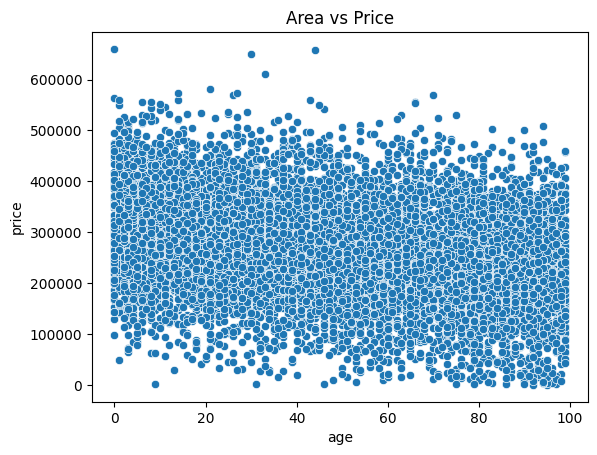

In [76]:
sns.scatterplot(x='age', y='price', data=df)
plt.title("Area vs Price")

Text(0.5, 1.0, 'distance_to_city(km) vs Price')

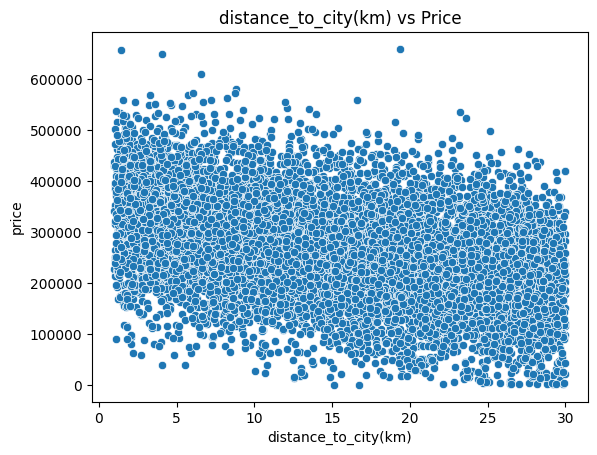

In [77]:
sns.scatterplot(x='distance_to_city(km)', y='price', data=df)
plt.title("distance_to_city(km) vs Price")

In [9]:
df['price'] = df['price'].abs()


Text(0.5, 1.0, 'Distribution of Price')

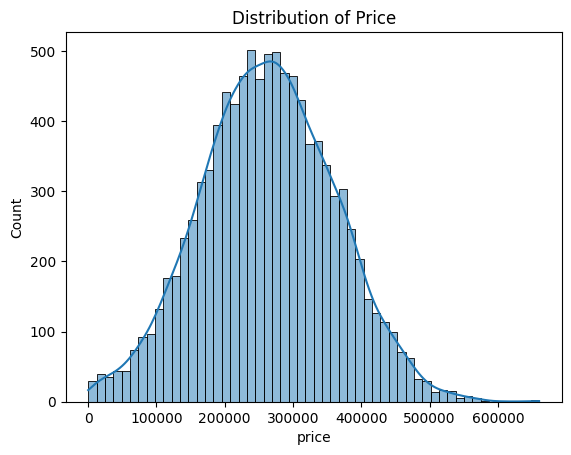

In [10]:
sns.histplot(df['price'], kde=True)
plt.title("Distribution of Price")

In [62]:
X_train, X_temp, y_train, y_temp = train_test_split(df.drop('price', axis=1), df['price'], test_size=0.2, random_state=42)

In [63]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [64]:
lr = LinearRegression()
dr = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

models = {
    'Linear Regression': lr,
    'Decision Tree': dr,
    'Random Forest': rf
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.2f}")

Linear Regression - MAE: 15633.85, MSE: 388901012.09, R²: 0.96
Decision Tree - MAE: 25334.52, MSE: 1006110207.04, R²: 0.89
Random Forest - MAE: 18213.46, MSE: 514721113.68, R²: 0.95


In [70]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    # Change 'input_shape' from 10 to 4
    layers.Dense(512, activation='relu', input_shape=(4,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'), 
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

plot_history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)

y_pred_nn = model.predict(X_val)
mae_nn = mean_squared_error(y_val, y_pred_nn)
print(f"Neural Network - MAE: {mae_nn:.2f}")
r2_nn = r2_score(y_val, y_pred_nn)
print(f"Neural Network - R²: {r2_nn:.2f}")

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13527277568.0000 - val_loss: 3932568320.0000
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3626682624.0000 - val_loss: 3422426112.0000
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2804210688.0000 - val_loss: 2258391296.0000
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1968604160.0000 - val_loss: 1499539200.0000
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1344945152.0000 - val_loss: 1149487872.0000
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 954999168.0000 - val_loss: 804420864.0000
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 701030400.0000 - val_loss: 685553280.0000
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 497582912.0000 - val_loss: 494820608.0000
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 459647616.0000 - val_loss: 393341728.0000
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 432445312.

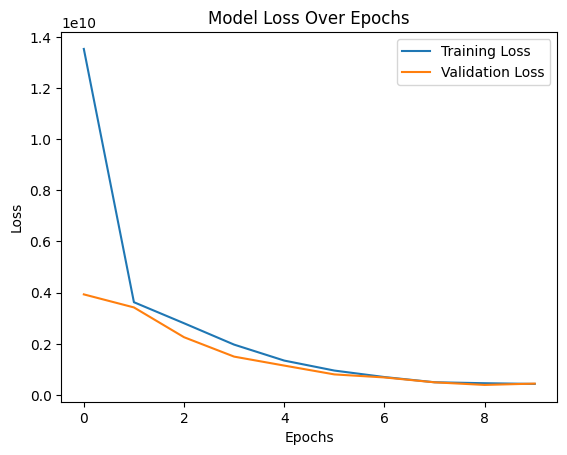

In [71]:
plt.plot(plot_history.history['loss'], label='Training Loss')
plt.plot(plot_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

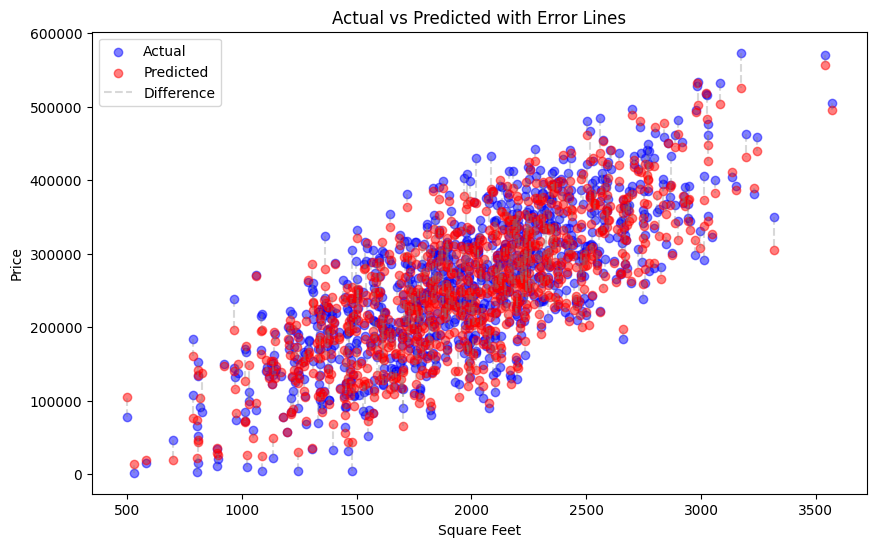

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. Plot actual values (blue dots)
plt.scatter(X_val["square_feet"], y_val, color='blue', label='Actual', alpha=0.5)

# 2. Plot predicted values (red dots)
plt.scatter(X_val["square_feet"], y_pred_nn, color='red', label='Predicted', alpha=0.5)

# 3. Draw the vertical lines connecting Actual to Predicted
# Format: vlines(x, y_start, y_end)
plt.vlines(X_val["square_feet"], y_val, y_pred_nn, color='gray', linestyle='--', alpha=0.3, label='Difference')

plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Actual vs Predicted with Error Lines")
plt.legend()
plt.show()


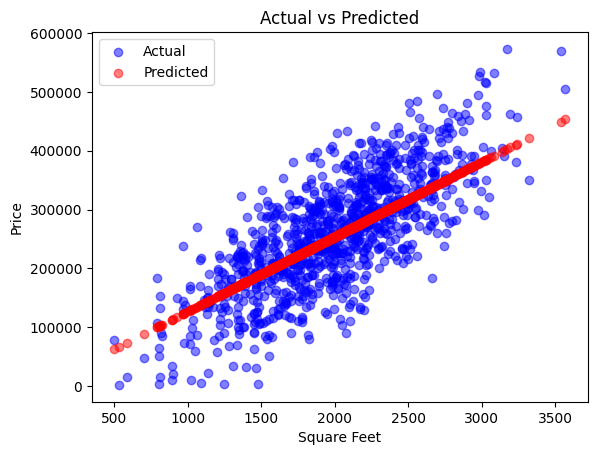

In [68]:
plt.scatter(X_val["square_feet"], y_val, color='blue', label='Actual', alpha=0.5)
plt.scatter(X_val["square_feet"], y_pred_nn, color='red', label='Predicted', alpha=0.5)
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Actual vs Predicted")
plt.legend(["Actual", "Predicted"])
plt.show()

In [78]:
import pickle

# Save the model
with open('house_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as house_model.pkl")


Model saved as house_model.pkl
